# Criação da Base V2

Este notebook cria a `Base_V2`, uma camada de features para análise de padrões entre filiais e preparação dos próximos modelos diários.

Agora ele consolida as ideias úteis encontradas nos materiais do grupo:

- BC: flags de dia útil, primeiro/quinto dia útil e feriados bancários calculados em Python.
- Gustavo: lags e médias móveis para modelagem diária.
- Celso: preparação da `Base_V1`, features MED/N-MED, perfis temporais e matriz de clusterização.

Saídas principais:

- `features_filiais_diarias_V2.parquet`: uma linha por `codigo_filial` e `data`; principal base para a futura modelagem diária.
- `features_filiais_agregadas_V2.parquet`: uma linha por filial, consolidando o comportamento diário.
- `features_filiais_cluster_semana_dia_V2.parquet`: matriz tratada final para clusterização, com features gerais e ratios `semana_mes x dia_semana_num`.

Decisões:

- O alvo de faturamento continua sendo bruto.
- Devoluções/liquido continuam fora da V2 oficial por enquanto; entram como diagnóstico ou feature auxiliar em modelagem se necessário.
- As features MED/N-MED usam a `vendas_V1`, portanto representam faturamento bruto por categoria.
- Lags e médias móveis são úteis para modelo diário, mas devem ser usados com cuidado em validação temporal.
- Taxas demográficas do BC ficam como pendência, pois os arquivos prontos de natalidade/mortalidade não estão disponíveis no projeto atual.
- A base diária V2 inclui estatísticas históricas completas da filial, repetidas em cada dia. Elas ajudam na exploração e seleção de features, mas não devem ser levadas automaticamente para o modelo final.
- A matriz de clusterização salva corresponde à Base B, pois equilibra interpretabilidade e estabilidade.


In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler


BASE_V1 = Path.cwd() / "Base_V1"
BASE_V2 = Path.cwd() / "Base_V2"

ARQUIVOS_V1 = {
    "filiais": "filiais_V1.parquet",
    "vendas": "vendas_V1.parquet",
    "vendas_diaria": "vendas_diaria_V1.parquet",
}

CHECKPOINTS_V2 = {
    "features_diarias": "features_filiais_diarias_V2.parquet",
    "features_agregadas": "features_filiais_agregadas_V2.parquet",
    "features_cluster_semana_dia": "features_filiais_cluster_semana_dia_V2.parquet",
}

COLUNAS_CADASTRAIS = [
    "codigo_filial",
    "faixa_vida",
    "localidade",
    "uf",
    "tipo_estabelecimento",
    "delivery",
    "metragem_area_venda",
    "panvel_clinic",
    "estacionamento",
    "atendimento_24_horas",
    "grupo_metragem",
    "idade_filial_meses",
    "idade_filial",
]

PCA_VARIANCIA_RATIO = 0.90

MAPA_DIA_SEMANA = {
    0: "segunda-feira",
    1: "terca-feira",
    2: "quarta-feira",
    3: "quinta-feira",
    4: "sexta-feira",
    5: "sabado",
    6: "domingo",
}

PALETA = {
    "azul": "#2563EB",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "cinza": "#4B5563",
    "cinza_claro": "#E5E7EB",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
})


## Funções auxiliares


In [2]:
def padronizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    return texto


def normalizar_codigo_filial(serie):
    return serie.astype(str).str.strip()


def dividir_seguro(numerador, denominador):
    numerador = pd.Series(numerador)
    denominador = pd.Series(denominador)
    resultado = numerador.div(denominador.replace(0, np.nan))
    return resultado.replace([np.inf, -np.inf], np.nan).fillna(0)


def calcular_pascoa(ano):
    a = ano % 19
    b = ano // 100
    c = ano % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    mes = (h + l - 7 * m + 114) // 31
    dia = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(ano, mes, dia)


def listar_feriados_bancarios(anos):
    feriados = set()

    for ano in sorted(pd.Series(anos).dropna().astype(int).unique()):
        pascoa = calcular_pascoa(ano)
        datas_fixas = [
            (1, 1),
            (4, 21),
            (5, 1),
            (9, 7),
            (10, 12),
            (11, 2),
            (11, 15),
            (12, 25),
        ]

        for mes, dia in datas_fixas:
            feriados.add(pd.Timestamp(ano, mes, dia).normalize())

        for deslocamento in [-48, -47, -2, 60]:
            feriados.add((pascoa + pd.Timedelta(days=deslocamento)).normalize())

        fechamento_bancario = pd.Timestamp(ano, 12, 31)
        while fechamento_bancario.dayofweek >= 5:
            fechamento_bancario -= pd.Timedelta(days=1)
        feriados.add(fechamento_bancario.normalize())

    return pd.DatetimeIndex(sorted(feriados))


def adicionar_features_dia_util(df, coluna_data="data"):
    datas = df[[coluna_data]].drop_duplicates().copy()
    datas[coluna_data] = pd.to_datetime(datas[coluna_data], errors="coerce").dt.normalize()
    datas["ano_calendario"] = datas[coluna_data].dt.year
    datas["mes_calendario"] = datas[coluna_data].dt.month
    feriados = listar_feriados_bancarios(datas["ano_calendario"])

    datas["eh_feriado_bancario"] = datas[coluna_data].isin(feriados).astype(int)
    datas["eh_fim_semana"] = datas[coluna_data].dt.dayofweek.isin([5, 6]).astype(int)
    datas["eh_dia_util"] = (
        datas["eh_fim_semana"].eq(0) & datas["eh_feriado_bancario"].eq(0)
    ).astype(int)

    uteis = datas.loc[datas["eh_dia_util"].eq(1), [coluna_data, "ano_calendario", "mes_calendario"]].copy()
    uteis = uteis.sort_values(coluna_data)
    uteis["ordem_dia_util_mes"] = uteis.groupby(["ano_calendario", "mes_calendario"]).cumcount() + 1

    dias_uteis_mes = (
        uteis.groupby(["ano_calendario", "mes_calendario"], as_index=False)
        .agg(dias_uteis_no_mes=("ordem_dia_util_mes", "max"))
    )

    datas = datas.merge(
        uteis[[coluna_data, "ordem_dia_util_mes"]],
        on=coluna_data,
        how="left",
    ).merge(
        dias_uteis_mes,
        on=["ano_calendario", "mes_calendario"],
        how="left",
    )

    datas["ordem_dia_util_mes"] = datas["ordem_dia_util_mes"].fillna(0).astype(int)
    datas["dias_uteis_no_mes"] = datas["dias_uteis_no_mes"].fillna(0).astype(int)
    datas["eh_primeiro_dia_util_mes"] = datas["ordem_dia_util_mes"].eq(1).astype(int)
    datas["eh_quinto_dia_util_mes"] = datas["ordem_dia_util_mes"].eq(5).astype(int)
    datas = datas.drop(columns=["ano_calendario", "mes_calendario"])

    return df.merge(datas, on=coluna_data, how="left")


def ler_base_v1(base_dir=BASE_V1):
    datasets = {}
    faltando = []

    for nome, arquivo in ARQUIVOS_V1.items():
        caminho = Path(base_dir) / arquivo
        if caminho.exists():
            datasets[nome] = pd.read_parquet(caminho)
        else:
            faltando.append(str(caminho))

    if faltando:
        raise FileNotFoundError(
            "Arquivos nao encontrados:\n- " + "\n- ".join(faltando)
        )

    for df in datasets.values():
        if "codigo_filial" in df.columns:
            df["codigo_filial"] = normalizar_codigo_filial(df["codigo_filial"])

    filiais = datasets["filiais"].copy()
    for coluna in filiais.columns:
        if coluna != "codigo_filial" and pd.api.types.is_string_dtype(filiais[coluna]):
            filiais[coluna] = filiais[coluna].map(padronizar_texto)

    datasets["filiais"] = filiais
    return datasets


def adicionar_features_calendario(df, coluna_data="data"):
    df = df.copy()
    df[coluna_data] = pd.to_datetime(df[coluna_data], errors="coerce").dt.tz_localize(None).dt.normalize()
    df["ano"] = df[coluna_data].dt.year
    df["mes"] = df[coluna_data].dt.month
    df["dia_mes"] = df[coluna_data].dt.day
    df["semana_mes"] = ((df["dia_mes"] - 1) // 7 + 1).astype("Int64")
    df["semana_ano"] = df[coluna_data].dt.isocalendar().week.astype("Int64")
    df["dia_semana_num"] = df[coluna_data].dt.dayofweek
    df["dia_semana"] = df["dia_semana_num"].map(MAPA_DIA_SEMANA)
    df["trimestre"] = df[coluna_data].dt.quarter
    df["semestre"] = np.where(df["mes"] <= 6, 1, 2)
    df["eh_semana_5"] = df["semana_mes"].eq(5).astype(int)
    df["dias_no_mes"] = df[coluna_data].dt.days_in_month
    df["eh_inicio_mes"] = df["dia_mes"].le(7).astype(int)
    df["eh_fim_mes"] = (df["dias_no_mes"] - df["dia_mes"]).le(6).astype(int)
    df["periodo_ordem"] = df[coluna_data].dt.strftime("%Y%m%d").astype(int)
    df = adicionar_features_dia_util(df, coluna_data)
    return df


def montar_grade_diaria(filiais, vendas_diaria):
    datas_filial = (
        vendas_diaria.assign(data=pd.to_datetime(vendas_diaria["data"], errors="coerce"))
        .groupby("codigo_filial", as_index=False)
        .agg(primeira_data_venda=("data", "min"))
    )
    data_max = pd.to_datetime(vendas_diaria["data"], errors="coerce").max()

    linhas = []
    for _, linha in datas_filial.iterrows():
        datas = pd.date_range(linha["primeira_data_venda"], data_max, freq="D")
        linhas.append(pd.DataFrame({
            "codigo_filial": linha["codigo_filial"],
            "data": datas,
            "primeira_data_venda": linha["primeira_data_venda"],
        }))

    grade = pd.concat(linhas, ignore_index=True)
    grade["dias_desde_primeira_venda"] = (grade["data"] - grade["primeira_data_venda"]).dt.days
    grade = adicionar_features_calendario(grade, "data")

    colunas_disponiveis = [coluna for coluna in COLUNAS_CADASTRAIS if coluna in filiais.columns]
    filiais_cadastro = filiais[colunas_disponiveis].drop_duplicates("codigo_filial").copy()
    return grade.merge(filiais_cadastro, on="codigo_filial", how="left")


In [3]:
def construir_features_diarias_categoria(vendas):
    vendas = vendas.copy()
    vendas["data"] = pd.to_datetime(vendas["data_emissao_data"], errors="coerce")

    quantidade = pd.to_numeric(vendas["quantidade"], errors="coerce").fillna(0)
    categoria = vendas["categoria_gerencial"].astype(str).str.strip().str.upper()

    vendas["faturamento_med_dia"] = np.where(categoria.eq("MED"), vendas["faturamento"], 0)
    vendas["faturamento_n_med_dia"] = np.where(categoria.eq("N-MED"), vendas["faturamento"], 0)
    vendas["quantidade_med_dia"] = np.where(categoria.eq("MED"), quantidade, 0)
    vendas["quantidade_n_med_dia"] = np.where(categoria.eq("N-MED"), quantidade, 0)

    return (
        vendas.groupby(["codigo_filial", "data"], as_index=False)
        .agg(
            faturamento_med_dia=("faturamento_med_dia", "sum"),
            faturamento_n_med_dia=("faturamento_n_med_dia", "sum"),
            quantidade_med_dia=("quantidade_med_dia", "sum"),
            quantidade_n_med_dia=("quantidade_n_med_dia", "sum"),
        )
    )


def adicionar_features_lag_modelagem(features):
    features = features.sort_values(["codigo_filial", "data"]).copy()
    grupo = features.groupby("codigo_filial", group_keys=False)

    for lag in [1, 7, 14, 28]:
        features[f"faturamento_bruto_lag_{lag}d"] = grupo["faturamento_bruto_dia"].shift(lag)

    for coluna, prefixo in [
        ("cupons_dia", "cupons"),
        ("quantidade_dia", "quantidade"),
        ("faturamento_med_dia", "faturamento_med"),
        ("faturamento_n_med_dia", "faturamento_n_med"),
        ("share_med_faturamento", "share_med_faturamento"),
    ]:
        features[f"{prefixo}_lag_7d"] = grupo[coluna].shift(7)

    for janela in [7, 28]:
        features[f"faturamento_bruto_media_movel_{janela}d"] = grupo["faturamento_bruto_dia"].transform(
            lambda serie: serie.shift(1).rolling(window=janela, min_periods=1).mean()
        )
        features[f"faturamento_bruto_std_movel_{janela}d"] = grupo["faturamento_bruto_dia"].transform(
            lambda serie: serie.shift(1).rolling(window=janela, min_periods=2).std()
        )

    for coluna, prefixo in [
        ("cupons_dia", "cupons"),
        ("quantidade_dia", "quantidade"),
        ("faturamento_med_dia", "faturamento_med"),
        ("faturamento_n_med_dia", "faturamento_n_med"),
    ]:
        features[f"{prefixo}_media_movel_28d"] = grupo[coluna].transform(
            lambda serie: serie.shift(1).rolling(window=28, min_periods=1).mean()
        )

    colunas_historicas = [
        coluna for coluna in features.columns
        if "_lag_" in coluna or "_media_movel_" in coluna or "_std_movel_" in coluna
    ]
    features[colunas_historicas] = features[colunas_historicas].fillna(0)
    return features


def construir_perfil_calendario_diario(features):
    features = features.copy()

    media_mes_dia_semana = features.groupby(
        ["codigo_filial", "mes", "dia_semana_num"]
    )["faturamento_bruto_dia"].transform("mean")
    media_mes = features.groupby(
        ["codigo_filial", "mes"]
    )["faturamento_bruto_dia"].transform("mean")
    features["faturamento_bruto_ratio_mes_dia_semana"] = dividir_seguro(
        media_mes_dia_semana,
        media_mes,
    )

    chaves_mes = ["codigo_filial", "mes"]
    media_mes_slot = (
        features.groupby(chaves_mes, as_index=False)
        .agg(faturamento_bruto_media_mes=("faturamento_bruto_dia", "mean"))
    )

    chaves = ["codigo_filial", "mes", "semana_mes", "dia_semana_num"]
    perfil = (
        features.groupby(chaves, as_index=False)
        .agg(
            faturamento_bruto_media_mes_semana_dia=("faturamento_bruto_dia", "mean"),
            faturamento_bruto_std_mes_semana_dia=("faturamento_bruto_dia", "std"),
            faturamento_bruto_obs_mes_semana_dia=("faturamento_bruto_dia", "size"),
        )
        .merge(media_mes_slot, on=chaves_mes, how="left")
    )
    perfil["faturamento_bruto_std_mes_semana_dia"] = perfil["faturamento_bruto_std_mes_semana_dia"].fillna(0)
    perfil["faturamento_bruto_cv_mes_semana_dia"] = dividir_seguro(
        perfil["faturamento_bruto_std_mes_semana_dia"],
        perfil["faturamento_bruto_media_mes_semana_dia"],
    )
    perfil["faturamento_bruto_ratio_mes_semana_dia"] = dividir_seguro(
        perfil["faturamento_bruto_media_mes_semana_dia"],
        perfil["faturamento_bruto_media_mes"],
    )
    perfil = perfil.drop(columns="faturamento_bruto_media_mes")

    return features.merge(perfil, on=chaves, how="left")


def construir_features_diarias(grade, vendas_diaria, vendas):
    diaria = vendas_diaria.copy()
    diaria["data"] = pd.to_datetime(diaria["data"], errors="coerce")

    categoria_diaria = construir_features_diarias_categoria(vendas)

    features = grade.merge(
        diaria[[
            "codigo_filial",
            "data",
            "cupons_dia",
            "quantidade_dia",
            "faturamento_bruto_dia",
        ]],
        on=["codigo_filial", "data"],
        how="left",
    ).merge(
        categoria_diaria,
        on=["codigo_filial", "data"],
        how="left",
    )

    metricas = [
        "cupons_dia",
        "quantidade_dia",
        "faturamento_bruto_dia",
        "faturamento_med_dia",
        "faturamento_n_med_dia",
        "quantidade_med_dia",
        "quantidade_n_med_dia",
    ]
    features[metricas] = features[metricas].fillna(0)
    features["teve_venda"] = features["cupons_dia"].gt(0).astype(int)
    features["ticket_medio_bruto_dia"] = dividir_seguro(features["faturamento_bruto_dia"], features["cupons_dia"])
    features["itens_por_cupom_dia"] = dividir_seguro(features["quantidade_dia"], features["cupons_dia"])

    faturamento_categoria = features["faturamento_med_dia"] + features["faturamento_n_med_dia"]
    quantidade_categoria = features["quantidade_med_dia"] + features["quantidade_n_med_dia"]
    features["share_med_faturamento"] = dividir_seguro(features["faturamento_med_dia"], faturamento_categoria)
    features["share_n_med_faturamento"] = dividir_seguro(features["faturamento_n_med_dia"], faturamento_categoria)
    features["share_med_quantidade"] = dividir_seguro(features["quantidade_med_dia"], quantidade_categoria)
    features["share_n_med_quantidade"] = dividir_seguro(features["quantidade_n_med_dia"], quantidade_categoria)

    features = adicionar_features_lag_modelagem(features)
    features = construir_perfil_calendario_diario(features)

    colunas_inicio = [
        "codigo_filial",
        "data",
        "ano",
        "mes",
        "dia_mes",
        "semana_mes",
        "semana_ano",
        "dia_semana_num",
        "dia_semana",
        "trimestre",
        "semestre",
        "eh_semana_5",
        "eh_fim_semana",
        "eh_feriado_bancario",
        "eh_dia_util",
        "ordem_dia_util_mes",
        "dias_uteis_no_mes",
        "eh_primeiro_dia_util_mes",
        "eh_quinto_dia_util_mes",
        "eh_inicio_mes",
        "eh_fim_mes",
        "dias_no_mes",
        "periodo_ordem",
        "primeira_data_venda",
        "dias_desde_primeira_venda",
    ]
    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    demais_colunas = [coluna for coluna in features.columns if coluna not in colunas_inicio + colunas_cadastro]
    return features[colunas_inicio + colunas_cadastro + demais_colunas]


In [4]:
def construir_features_agregadas(features_diarias):
    dia = features_diarias.copy()

    agregadas = (
        dia.groupby("codigo_filial", as_index=False)
        .agg(
            dias_total=("data", "nunique"),
            dias_com_venda_total=("teve_venda", "sum"),
            faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
            faturamento_bruto_medio_dia=("faturamento_bruto_dia", "mean"),
            faturamento_bruto_mediano_dia=("faturamento_bruto_dia", "median"),
            faturamento_bruto_std_dia=("faturamento_bruto_dia", "std"),
            faturamento_bruto_max_dia=("faturamento_bruto_dia", "max"),
            faturamento_bruto_min_dia=("faturamento_bruto_dia", "min"),
            quantidade_total=("quantidade_dia", "sum"),
            quantidade_media_dia=("quantidade_dia", "mean"),
            cupons_total=("cupons_dia", "sum"),
            cupons_medios_dia=("cupons_dia", "mean"),
            ticket_medio_bruto_dia_medio=("ticket_medio_bruto_dia", "mean"),
            itens_por_cupom_dia_medio=("itens_por_cupom_dia", "mean"),
            faturamento_med_total=("faturamento_med_dia", "sum"),
            faturamento_n_med_total=("faturamento_n_med_dia", "sum"),
            quantidade_med_total=("quantidade_med_dia", "sum"),
            quantidade_n_med_total=("quantidade_n_med_dia", "sum"),
            share_med_faturamento_medio=("share_med_faturamento", "mean"),
            share_n_med_faturamento_medio=("share_n_med_faturamento", "mean"),
            share_med_quantidade_medio=("share_med_quantidade", "mean"),
            share_n_med_quantidade_medio=("share_n_med_quantidade", "mean"),
        )
    )

    chaves_calendario = ["codigo_filial", "mes", "semana_mes", "dia_semana_num"]
    colunas_calendario = [
        "faturamento_bruto_media_mes_semana_dia",
        "faturamento_bruto_std_mes_semana_dia",
        "faturamento_bruto_cv_mes_semana_dia",
        "faturamento_bruto_obs_mes_semana_dia",
        "faturamento_bruto_ratio_mes_semana_dia",
    ]
    perfil_calendario = dia[chaves_calendario + colunas_calendario].drop_duplicates(chaves_calendario)
    resumo_calendario = (
        perfil_calendario.groupby("codigo_filial", as_index=False)
        .agg(
            faturamento_bruto_media_calendario_medio=("faturamento_bruto_media_mes_semana_dia", "mean"),
            faturamento_bruto_std_calendario_medio=("faturamento_bruto_std_mes_semana_dia", "mean"),
            faturamento_bruto_cv_calendario_medio=("faturamento_bruto_cv_mes_semana_dia", "mean"),
            faturamento_bruto_ratio_calendario_medio=("faturamento_bruto_ratio_mes_semana_dia", "mean"),
            faturamento_bruto_obs_calendario_medio=("faturamento_bruto_obs_mes_semana_dia", "mean"),
            faturamento_bruto_obs_calendario_min=("faturamento_bruto_obs_mes_semana_dia", "min"),
            faturamento_bruto_obs_calendario_max=("faturamento_bruto_obs_mes_semana_dia", "max"),
            slots_calendario_total=("faturamento_bruto_obs_mes_semana_dia", "size"),
        )
    )
    agregadas = agregadas.merge(resumo_calendario, on="codigo_filial", how="left")

    agregadas["pct_dias_com_venda"] = dividir_seguro(agregadas["dias_com_venda_total"], agregadas["dias_total"])
    agregadas["cv_faturamento_bruto_dia"] = dividir_seguro(
        agregadas["faturamento_bruto_std_dia"],
        agregadas["faturamento_bruto_medio_dia"],
    )
    agregadas["share_med_faturamento_total"] = dividir_seguro(
        agregadas["faturamento_med_total"],
        agregadas["faturamento_med_total"] + agregadas["faturamento_n_med_total"],
    )
    agregadas["share_n_med_faturamento_total"] = dividir_seguro(
        agregadas["faturamento_n_med_total"],
        agregadas["faturamento_med_total"] + agregadas["faturamento_n_med_total"],
    )
    agregadas["share_med_quantidade_total"] = dividir_seguro(
        agregadas["quantidade_med_total"],
        agregadas["quantidade_med_total"] + agregadas["quantidade_n_med_total"],
    )
    agregadas["share_n_med_quantidade_total"] = dividir_seguro(
        agregadas["quantidade_n_med_total"],
        agregadas["quantidade_med_total"] + agregadas["quantidade_n_med_total"],
    )

    cadastro = dia[COLUNAS_CADASTRAIS].drop_duplicates("codigo_filial").reset_index(drop=True)
    agregadas = agregadas.merge(cadastro, on="codigo_filial", how="left")
    agregadas = agregadas.replace([np.inf, -np.inf], np.nan)
    colunas_numericas = agregadas.select_dtypes(include="number").columns
    agregadas[colunas_numericas] = agregadas[colunas_numericas].fillna(0)

    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    demais_colunas = [coluna for coluna in agregadas.columns if coluna not in ["codigo_filial"] + colunas_cadastro]
    return agregadas[["codigo_filial"] + colunas_cadastro + demais_colunas]


def pivotar_perfil_temporal(perfil, coluna_valor, prefixo):
    pivot = perfil.pivot_table(
        index="codigo_filial",
        columns="chave_calendario",
        values=coluna_valor,
        aggfunc="first",
    )
    pivot.columns = [f"{prefixo}_{coluna}" for coluna in pivot.columns]
    return pivot.reset_index()


def construir_features_agregadas_cluster(features_diarias, features_agregadas):
    chaves_calendario = ["codigo_filial", "mes", "semana_mes", "dia_semana_num"]
    perfil_calendario = (
        features_diarias[
            chaves_calendario + [
                "faturamento_bruto_ratio_mes_semana_dia",
                "faturamento_bruto_cv_mes_semana_dia",
                "faturamento_bruto_obs_mes_semana_dia",
            ]
        ]
        .drop_duplicates(chaves_calendario)
        .copy()
    )

    perfil_calendario["chave_calendario"] = (
        "mes" + perfil_calendario["mes"].astype(str).str.zfill(2)
        + "_sem" + perfil_calendario["semana_mes"].astype(str)
        + "_dow" + perfil_calendario["dia_semana_num"].astype(str)
    )

    pivots = [
        pivotar_perfil_temporal(perfil_calendario, "faturamento_bruto_ratio_mes_semana_dia", "ratio"),
        pivotar_perfil_temporal(perfil_calendario, "faturamento_bruto_cv_mes_semana_dia", "cv"),
        pivotar_perfil_temporal(perfil_calendario, "faturamento_bruto_obs_mes_semana_dia", "obs"),
    ]

    cluster = features_agregadas.copy()
    for pivot in pivots:
        cluster = cluster.merge(pivot, on="codigo_filial", how="left")

    ratio_cols = [coluna for coluna in cluster.columns if coluna.startswith("ratio_")]
    cv_cols = [coluna for coluna in cluster.columns if coluna.startswith("cv_")]
    obs_cols = [coluna for coluna in cluster.columns if coluna.startswith("obs_")]

    cluster[ratio_cols] = cluster[ratio_cols].fillna(1)
    cluster[cv_cols] = cluster[cv_cols].fillna(0)
    cluster[obs_cols] = cluster[obs_cols].fillna(0)
    return cluster


def construir_features_agregadas_cluster_semana_dia(features_diarias, features_agregadas):
    dia = features_diarias.copy()
    media_filial = (
        dia.groupby("codigo_filial", as_index=False)
        .agg(faturamento_bruto_media_filial=("faturamento_bruto_dia", "mean"))
    )

    perfil_semana_dia = (
        dia.groupby(["codigo_filial", "semana_mes", "dia_semana_num"], as_index=False)
        .agg(
            faturamento_bruto_media_semana_dia=("faturamento_bruto_dia", "mean"),
            faturamento_bruto_std_semana_dia=("faturamento_bruto_dia", "std"),
            faturamento_bruto_obs_semana_dia=("faturamento_bruto_dia", "size"),
        )
        .merge(media_filial, on="codigo_filial", how="left")
    )
    perfil_semana_dia["faturamento_bruto_std_semana_dia"] = perfil_semana_dia["faturamento_bruto_std_semana_dia"].fillna(0)
    perfil_semana_dia["faturamento_bruto_ratio_semana_dia"] = dividir_seguro(
        perfil_semana_dia["faturamento_bruto_media_semana_dia"],
        perfil_semana_dia["faturamento_bruto_media_filial"],
    )
    perfil_semana_dia["faturamento_bruto_cv_semana_dia"] = dividir_seguro(
        perfil_semana_dia["faturamento_bruto_std_semana_dia"],
        perfil_semana_dia["faturamento_bruto_media_semana_dia"],
    )
    perfil_semana_dia["chave_calendario"] = (
        "sem" + perfil_semana_dia["semana_mes"].astype(str)
        + "_dow" + perfil_semana_dia["dia_semana_num"].astype(str)
    )

    perfil_mes = (
        dia.groupby(["codigo_filial", "mes"], as_index=False)
        .agg(faturamento_bruto_media_mes=("faturamento_bruto_dia", "mean"))
        .merge(media_filial, on="codigo_filial", how="left")
    )
    perfil_mes["faturamento_bruto_ratio_mes"] = dividir_seguro(
        perfil_mes["faturamento_bruto_media_mes"],
        perfil_mes["faturamento_bruto_media_filial"],
    )
    perfil_mes["chave_calendario"] = "mes" + perfil_mes["mes"].astype(str).str.zfill(2)

    pivots = [
        pivotar_perfil_temporal(perfil_semana_dia, "faturamento_bruto_ratio_semana_dia", "ratio_semana_dia"),
        pivotar_perfil_temporal(perfil_semana_dia, "faturamento_bruto_cv_semana_dia", "cv_semana_dia"),
        pivotar_perfil_temporal(perfil_semana_dia, "faturamento_bruto_obs_semana_dia", "obs_semana_dia"),
        pivotar_perfil_temporal(perfil_mes, "faturamento_bruto_ratio_mes", "ratio_mensal"),
    ]

    cluster = features_agregadas.copy()
    for pivot in pivots:
        cluster = cluster.merge(pivot, on="codigo_filial", how="left")

    ratio_cols = [coluna for coluna in cluster.columns if coluna.startswith(("ratio_semana_dia_", "ratio_mensal_"))]
    cv_cols = [coluna for coluna in cluster.columns if coluna.startswith("cv_semana_dia_")]
    obs_cols = [coluna for coluna in cluster.columns if coluna.startswith("obs_semana_dia_")]

    cluster[ratio_cols] = cluster[ratio_cols].fillna(1)
    cluster[cv_cols] = cluster[cv_cols].fillna(0)
    cluster[obs_cols] = cluster[obs_cols].fillna(0)
    return cluster


def tratar_features_gerais(gerais):
    colunas_categoricas = [
        coluna for coluna in gerais.select_dtypes(include=["object", "category"]).columns
        if coluna != "codigo_filial"
    ]
    colunas_numericas = [
        coluna for coluna in gerais.select_dtypes(include="number").columns
        if coluna != "codigo_filial"
    ]

    matriz_geral = []
    nomes_gerais = []

    if colunas_numericas:
        numericas = gerais[colunas_numericas].apply(pd.to_numeric, errors="coerce")
        numericas = numericas.fillna(numericas.median(numeric_only=True)).fillna(0)
        scaler_numericas = StandardScaler()
        matriz_geral.append(scaler_numericas.fit_transform(numericas))
        nomes_gerais.extend([f"num__{coluna}" for coluna in colunas_numericas])

    if colunas_categoricas:
        categoricas = gerais[colunas_categoricas].astype("object").fillna("SEM_INFO")
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        matriz_geral.append(encoder.fit_transform(categoricas))
        nomes_gerais.extend([f"cat__{coluna}" for coluna in encoder.get_feature_names_out(colunas_categoricas)])

    if matriz_geral:
        matriz_geral = np.hstack(matriz_geral)
    else:
        matriz_geral = np.empty((len(gerais), 0))

    return pd.DataFrame(matriz_geral, columns=nomes_gerais, index=gerais.index)


def padronizar_bloco_temporal(cluster, colunas, prefixo_saida, valor_neutro=1):
    if not colunas:
        return pd.DataFrame(index=cluster.index)

    valores = cluster[colunas].apply(pd.to_numeric, errors="coerce").fillna(valor_neutro)
    scaler = StandardScaler()
    matriz = scaler.fit_transform(valores)
    nomes = [f"{prefixo_saida}__{coluna.replace(prefixo_saida + '_', '')}" for coluna in colunas]
    return pd.DataFrame(matriz, columns=nomes, index=cluster.index)


def construir_features_cluster_pca(features_agregadas_cluster, variancia_ratio=PCA_VARIANCIA_RATIO):
    cluster = features_agregadas_cluster.copy()

    colunas_ratio = [coluna for coluna in cluster.columns if coluna.startswith("ratio_mes")]
    colunas_cv_wide = [coluna for coluna in cluster.columns if coluna.startswith("cv_mes")]
    colunas_obs_wide = [coluna for coluna in cluster.columns if coluna.startswith("obs_mes")]
    colunas_temporais_wide = colunas_ratio + colunas_cv_wide + colunas_obs_wide

    features_gerais_tratadas = tratar_features_gerais(cluster.drop(columns=colunas_temporais_wide))

    ratios = cluster[colunas_ratio].apply(pd.to_numeric, errors="coerce").fillna(1)
    scaler_ratio = StandardScaler()
    ratios_scaled = scaler_ratio.fit_transform(ratios)
    pca_ratio = PCA(n_components=variancia_ratio, svd_solver="full")
    componentes_ratio = pca_ratio.fit_transform(ratios_scaled)

    scaler_componentes = StandardScaler()
    componentes_ratio = scaler_componentes.fit_transform(componentes_ratio)

    nomes_pc = [f"pc_ratio_{indice:02d}" for indice in range(1, componentes_ratio.shape[1] + 1)]
    features_ratio_pca = pd.DataFrame(componentes_ratio, columns=nomes_pc, index=cluster.index)

    features_cluster_pca = pd.concat(
        [
            cluster[["codigo_filial"]].reset_index(drop=True),
            features_gerais_tratadas.reset_index(drop=True),
            features_ratio_pca.reset_index(drop=True),
        ],
        axis=1,
    )

    resumo_pca = pd.DataFrame({
        "componente": nomes_pc,
        "variancia_explicada": pca_ratio.explained_variance_ratio_,
        "variancia_explicada_acumulada": np.cumsum(pca_ratio.explained_variance_ratio_),
    })

    return features_cluster_pca, resumo_pca


def construir_features_cluster_semana_dia(features_agregadas_cluster_semana_dia, incluir_mensal=False):
    cluster = features_agregadas_cluster_semana_dia.copy()

    colunas_ratio_semana = [coluna for coluna in cluster.columns if coluna.startswith("ratio_semana_dia_")]
    colunas_cv_semana = [coluna for coluna in cluster.columns if coluna.startswith("cv_semana_dia_")]
    colunas_obs_semana = [coluna for coluna in cluster.columns if coluna.startswith("obs_semana_dia_")]
    colunas_ratio_mensal = [coluna for coluna in cluster.columns if coluna.startswith("ratio_mensal_")]
    colunas_temporais = colunas_ratio_semana + colunas_cv_semana + colunas_obs_semana + colunas_ratio_mensal

    features_gerais_tratadas = tratar_features_gerais(cluster.drop(columns=colunas_temporais))
    blocos = [
        cluster[["codigo_filial"]].reset_index(drop=True),
        features_gerais_tratadas.reset_index(drop=True),
        padronizar_bloco_temporal(cluster, colunas_ratio_semana, "ratio_semana_dia").reset_index(drop=True),
    ]

    if incluir_mensal:
        blocos.append(
            padronizar_bloco_temporal(cluster, colunas_ratio_mensal, "ratio_mensal").reset_index(drop=True)
        )

    return pd.concat(blocos, axis=1)


def adicionar_perfil_historico_filial(features_diarias, features_agregadas):
    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    colunas_perfil = [
        coluna for coluna in features_agregadas.columns
        if coluna not in ["codigo_filial"] + colunas_cadastro
    ]
    perfil = features_agregadas[["codigo_filial"] + colunas_perfil].copy()
    return features_diarias.merge(perfil, on="codigo_filial", how="left")


def salvar_checkpoints_v2(
    features_diarias,
    features_agregadas,
    features_cluster_semana_dia,
):
    BASE_V2.mkdir(parents=True, exist_ok=True)
    caminhos = {
        "features_diarias": BASE_V2 / CHECKPOINTS_V2["features_diarias"],
        "features_agregadas": BASE_V2 / CHECKPOINTS_V2["features_agregadas"],
        "features_cluster_semana_dia": BASE_V2 / CHECKPOINTS_V2["features_cluster_semana_dia"],
    }

    features_diarias.to_parquet(caminhos["features_diarias"], index=False)
    features_agregadas.to_parquet(caminhos["features_agregadas"], index=False)
    features_cluster_semana_dia.to_parquet(caminhos["features_cluster_semana_dia"], index=False)

    return {nome: str(caminho) for nome, caminho in caminhos.items()}


def validar_chaves(
    features_diarias,
    features_agregadas,
    features_agregadas_cluster,
    features_cluster_pca,
    features_agregadas_cluster_semana_dia,
    features_cluster_semana_dia,
    features_cluster_semana_dia_mes,
):
    validacoes = {
        "duplicadas_diarias": features_diarias.duplicated(["codigo_filial", "data"]).sum(),
        "duplicadas_agregadas": features_agregadas.duplicated(["codigo_filial"]).sum(),
        "duplicadas_agregadas_cluster": features_agregadas_cluster.duplicated(["codigo_filial"]).sum(),
        "duplicadas_cluster_pca": features_cluster_pca.duplicated(["codigo_filial"]).sum(),
        "duplicadas_agregadas_cluster_semana_dia": features_agregadas_cluster_semana_dia.duplicated(["codigo_filial"]).sum(),
        "duplicadas_cluster_semana_dia": features_cluster_semana_dia.duplicated(["codigo_filial"]).sum(),
        "duplicadas_cluster_semana_dia_mes": features_cluster_semana_dia_mes.duplicated(["codigo_filial"]).sum(),
    }

    for nome, valor in validacoes.items():
        if valor:
            raise ValueError(f"Falha em {nome}: {valor} duplicadas.")

    return pd.DataFrame({
        "validacao": list(validacoes.keys()) + [
            "filiais_base_diaria",
            "filiais_base_agregada",
            "filiais_base_agregada_cluster",
            "filiais_base_cluster_pca",
            "filiais_base_agregada_cluster_semana_dia",
            "filiais_base_cluster_semana_dia",
            "filiais_base_cluster_semana_dia_mes",
        ],
        "valor": list(validacoes.values()) + [
            features_diarias["codigo_filial"].nunique(),
            features_agregadas["codigo_filial"].nunique(),
            features_agregadas_cluster["codigo_filial"].nunique(),
            features_cluster_pca["codigo_filial"].nunique(),
            features_agregadas_cluster_semana_dia["codigo_filial"].nunique(),
            features_cluster_semana_dia["codigo_filial"].nunique(),
            features_cluster_semana_dia_mes["codigo_filial"].nunique(),
        ],
    })


In [5]:
def limpar_eixo(ax, grade="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grade, color=PALETA["cinza_claro"], linewidth=0.8)
    ax.set_axisbelow(True)


def plotar_resumo_base_v2(features_diarias, features_agregadas):
    mensal = (
        features_diarias.groupby(["ano", "mes"], as_index=False)
        .agg(faturamento_bruto=("faturamento_bruto_dia", "sum"))
    )
    mensal["periodo"] = pd.to_datetime(
        mensal["ano"].astype(str) + "-" + mensal["mes"].astype(str).str.zfill(2) + "-01"
    )

    por_dia_semana = (
        features_diarias.groupby(["dia_semana_num", "dia_semana"], as_index=False)
        .agg(faturamento_bruto_medio=("faturamento_bruto_dia", "mean"))
        .sort_values("dia_semana_num")
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(mensal["periodo"], mensal["faturamento_bruto"] / 1_000_000, marker="o", color=PALETA["azul"])
    axes[0].set_title("Faturamento bruto mensal - Base V2 diaria")
    axes[0].set_ylabel("R$ milhoes")
    axes[0].set_xlabel("")
    limpar_eixo(axes[0])

    axes[1].bar(por_dia_semana["dia_semana"], por_dia_semana["faturamento_bruto_medio"] / 1000, color=PALETA["laranja"])
    axes[1].set_title("Faturamento bruto medio por dia da semana")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("R$ mil")
    axes[1].tick_params(axis="x", rotation=25)
    limpar_eixo(axes[1])

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(features_agregadas["faturamento_bruto_medio_dia"] / 1000, bins=25, color=PALETA["verde"])
    axes[0].set_title("Distribuicao do faturamento bruto medio diario por filial")
    axes[0].set_xlabel("R$ mil")
    axes[0].set_ylabel("Filiais")
    limpar_eixo(axes[0])

    axes[1].scatter(
        features_agregadas["cupons_medios_dia"],
        features_agregadas["ticket_medio_bruto_dia_medio"],
        s=70,
        alpha=0.75,
        color=PALETA["azul"],
    )
    axes[1].set_title("Cupons medios x ticket medio bruto diario")
    axes[1].set_xlabel("Cupons medios por dia")
    axes[1].set_ylabel("Ticket medio bruto diario")
    limpar_eixo(axes[1])

    plt.tight_layout()
    plt.show()


def plotar_visualizacoes_complementares(features_diarias, features_agregadas):
    heatmap = (
        features_diarias.groupby(["mes", "dia_semana_num"])["faturamento_bruto_dia"]
        .mean()
        .unstack("dia_semana_num")
        .sort_index()
        / 1000
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    imagem = ax.imshow(heatmap, aspect="auto", cmap="Blues")
    ax.set_title("Faturamento bruto medio diario por mes e dia da semana")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Mes")
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"])
    ax.set_yticks(range(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index)
    cbar = plt.colorbar(imagem, ax=ax)
    cbar.set_label("R$ mil")
    plt.tight_layout()
    plt.show()

    mensal_mix = (
        features_diarias.loc[features_diarias["cupons_dia"].gt(0)]
        .groupby(["ano", "mes"], as_index=False)
        .agg(
            share_med=("share_med_faturamento", "mean"),
            share_n_med=("share_n_med_faturamento", "mean"),
        )
    )
    mensal_mix["periodo"] = pd.to_datetime(
        mensal_mix["ano"].astype(str) + "-" + mensal_mix["mes"].astype(str).str.zfill(2) + "-01"
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(mensal_mix["periodo"], mensal_mix["share_med"] * 100, marker="o", label="MED", color=PALETA["azul"])
    axes[0].plot(mensal_mix["periodo"], mensal_mix["share_n_med"] * 100, marker="o", label="N-MED", color=PALETA["laranja"])
    axes[0].set_title("Mix medio de faturamento bruto por mes")
    axes[0].set_ylabel("% do faturamento bruto")
    axes[0].set_xlabel("")
    axes[0].legend()
    limpar_eixo(axes[0])

    top = features_agregadas.nlargest(12, "faturamento_bruto_medio_dia").sort_values("faturamento_bruto_medio_dia")
    axes[1].barh(top["codigo_filial"], top["faturamento_bruto_medio_dia"] / 1000, color=PALETA["verde"])
    axes[1].set_title("Top filiais por faturamento bruto medio diario")
    axes[1].set_xlabel("R$ mil")
    axes[1].set_ylabel("Filial")
    limpar_eixo(axes[1], grade="x")

    plt.tight_layout()
    plt.show()


## Ler Base V1

Carrega as bases tratadas e elegíveis criadas em `Preparacao_bases`.


In [6]:
datasets = ler_base_v1()
filiais = datasets["filiais"]
vendas = datasets["vendas"]
vendas_diaria = datasets["vendas_diaria"]

resumo_leitura = pd.DataFrame({
    "base": ["filiais_V1", "vendas_V1", "vendas_diaria_V1"],
    "linhas": [len(filiais), len(vendas), len(vendas_diaria)],
    "colunas": [filiais.shape[1], vendas.shape[1], vendas_diaria.shape[1]],
    "filiais": [
        filiais["codigo_filial"].nunique(),
        vendas["codigo_filial"].nunique(),
        vendas_diaria["codigo_filial"].nunique(),
    ],
})

display(resumo_leitura)


,base,linhas,colunas,filiais
0,filiais_V1,100,13,100
1,vendas_V1,19565924,7,100
2,vendas_diaria_V1,72069,8,100


## Criar features diárias

A granularidade final é `codigo_filial + data`.

A grade diária começa na primeira data de venda de cada filial e vai até a última data da `Base_V1`. Isso evita criar zeros antes da filial aparecer na série e preserva eventuais dias sem venda depois da primeira venda.


In [7]:
grade_diaria = montar_grade_diaria(filiais, vendas_diaria)
features_diarias = construir_features_diarias(grade_diaria, vendas_diaria, vendas)
features_agregadas = construir_features_agregadas(features_diarias)
features_agregadas_cluster = construir_features_agregadas_cluster(features_diarias, features_agregadas)
features_cluster_pca, resumo_pca_ratio = construir_features_cluster_pca(features_agregadas_cluster)
features_agregadas_cluster_semana_dia = construir_features_agregadas_cluster_semana_dia(features_diarias, features_agregadas)
features_cluster_semana_dia = construir_features_cluster_semana_dia(
    features_agregadas_cluster_semana_dia,
    incluir_mensal=False,
)
features_cluster_semana_dia_mes = construir_features_cluster_semana_dia(
    features_agregadas_cluster_semana_dia,
    incluir_mensal=True,
)
features_diarias = adicionar_perfil_historico_filial(features_diarias, features_agregadas)

resumo_diario = pd.DataFrame({
    "indicador": [
        "filiais",
        "linhas na base diaria",
        "colunas na base diaria final",
        "data inicial",
        "data final",
        "faturamento bruto total",
        "dias com venda",
        "pct dias com venda",
        "share MED faturamento medio",
        "share N-MED faturamento medio",
        "ratio mes/dia semana medio",
        "ratio mes/semana/dia medio",
    ],
    "valor": [
        features_diarias["codigo_filial"].nunique(),
        features_diarias.shape[0],
        features_diarias.shape[1],
        features_diarias["data"].min().date(),
        features_diarias["data"].max().date(),
        features_diarias["faturamento_bruto_dia"].sum(),
        features_diarias["teve_venda"].sum(),
        features_diarias["teve_venda"].mean(),
        features_diarias.loc[features_diarias["cupons_dia"].gt(0), "share_med_faturamento"].mean(),
        features_diarias.loc[features_diarias["cupons_dia"].gt(0), "share_n_med_faturamento"].mean(),
        features_diarias["faturamento_bruto_ratio_mes_dia_semana"].mean(),
        features_diarias["faturamento_bruto_ratio_mes_semana_dia"].mean(),
    ],
})

display(resumo_diario)
display(features_diarias.head())


,indicador,valor
0,filiais,100
1,linhas na base diaria,73082
2,colunas na base diaria final,110
3,data inicial,2024-01-01
4,data final,2025-12-31
5,faturamento bruto total,5620320877.15
6,dias com venda,72069
7,pct dias com venda,0.986139
8,share MED faturamento medio,0.643468
9,share N-MED faturamento medio,0.356532


,codigo_filial,data,ano,mes,dia_mes,semana_mes,semana_ano,dia_semana_num,dia_semana,trimestre,...,faturamento_bruto_obs_calendario_medio,faturamento_bruto_obs_calendario_min,faturamento_bruto_obs_calendario_max,slots_calendario_total,pct_dias_com_venda,cv_faturamento_bruto_dia,share_med_faturamento_total,share_n_med_faturamento_total,share_med_quantidade_total,share_n_med_quantidade_total
0,1500,2024-01-02,2024,1,2,1,1,1,terca-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
1,1500,2024-01-03,2024,1,3,1,1,2,quarta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
2,1500,2024-01-04,2024,1,4,1,1,3,quinta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
3,1500,2024-01-05,2024,1,5,1,1,4,sexta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
4,1500,2024-01-06,2024,1,6,1,1,5,sabado,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564


## Dicionário da Base Diária

Explicação coluna por coluna da `features_filiais_diarias_V2`.

### Features Diárias

| coluna | descrição | como foi feita |
|---|---|---|
| `codigo_filial` | Identificador da filial. | Vem da `Base_V1`, padronizado como texto sem espaços. |
| `data` | Dia da observação. | Grade diária de cada filial, da primeira venda da filial até a última data da base. |
| `ano` | Ano da data. | Extraído de `data`. |
| `mes` | Mês da data, de 1 a 12. | Extraído de `data`. |
| `dia_mes` | Dia do mês. | Extraído de `data`. |
| `semana_mes` | Semana do mês, de 1 a 5. | Calculada por `((dia_mes - 1) // 7) + 1`. |
| `semana_ano` | Semana ISO do ano. | Extraída de `data.dt.isocalendar().week`. |
| `dia_semana_num` | Dia da semana numérico. | `0=segunda` até `6=domingo`; fim de semana pode ser derivado com valores 5 e 6. |
| `dia_semana` | Nome do dia da semana. | Mapeamento de `dia_semana_num`. |
| `trimestre` | Trimestre calendário. | Extraído de `data`. |
| `semestre` | Semestre calendário. | Meses 1 a 6 recebem 1; meses 7 a 12 recebem 2. |
| `eh_semana_5` | Indicador de semana 5 do mês. | 1 quando `semana_mes` é 5. |
| `eh_inicio_mes` | Indicador dos primeiros 7 dias do mês. | 1 quando `dia_mes <= 7`. |
| `eh_fim_mes` | Indicador dos últimos 7 dias do mês. | 1 quando faltam até 6 dias para o fim do mês. |
| `dias_no_mes` | Quantidade de dias no mês. | Extraído do calendário da data. |
| `periodo_ordem` | Código numérico para ordenar datas. | Data no formato `YYYYMMDD`. |
| `primeira_data_venda` | Primeira data com venda da filial na `Base_V1`. | Mínimo de `data` em `vendas_diaria_V1` por filial. |
| `dias_desde_primeira_venda` | Idade da filial dentro da série usada. | Diferença entre `data` e `primeira_data_venda`. |
| `faixa_vida` | Faixa de vida cadastrada da filial. | Vem de `filiais_V1`, padronizada em texto. |
| `tipo_estabelecimento` | Tipo cadastral da filial. | Vem de `filiais_V1`, padronizado em texto. |
| `delivery` | Indicador cadastral de delivery. | Vem de `filiais_V1`, padronizado em texto. |
| `metragem_area_venda` | Metragem da área de venda. | Vem de `filiais_V1`. |
| `panvel_clinic` | Indicador cadastral de Panvel Clinic. | Vem de `filiais_V1`, padronizado em texto. |
| `grupo_metragem` | Faixa/grupo de metragem da filial. | Vem de `filiais_V1`, padronizado em texto. |
| `teve_venda` | Indicador de venda no dia. | 1 quando `cupons_dia > 0`. |
| `faturamento_bruto_dia` | Faturamento bruto do dia. | Vem de `vendas_diaria_V1`; zero quando não há registro no dia. |
| `quantidade_dia` | Quantidade vendida no dia. | Vem de `vendas_diaria_V1`. |
| `cupons_dia` | Quantidade de cupons no dia. | Vem de `vendas_diaria_V1`. |
| `ticket_medio_bruto_dia` | Ticket médio bruto do dia. | `faturamento_bruto_dia / cupons_dia`. |
| `itens_por_cupom_dia` | Itens médios por cupom no dia. | `quantidade_dia / cupons_dia`. |
| `faturamento_med_dia` | Faturamento bruto MED do dia. | Soma de `faturamento` da `vendas_V1` quando `categoria_gerencial = MED`. |
| `faturamento_n_med_dia` | Faturamento bruto N-MED do dia. | Soma de `faturamento` da `vendas_V1` quando `categoria_gerencial = N-MED`. |
| `quantidade_med_dia` | Quantidade MED do dia. | Soma de `quantidade` da `vendas_V1` quando `categoria_gerencial = MED`. |
| `quantidade_n_med_dia` | Quantidade N-MED do dia. | Soma de `quantidade` da `vendas_V1` quando `categoria_gerencial = N-MED`. |
| `share_med_faturamento` | Share bruto MED no faturamento do dia. | `faturamento_med_dia / (faturamento_med_dia + faturamento_n_med_dia)`. |
| `share_n_med_faturamento` | Share bruto N-MED no faturamento do dia. | `faturamento_n_med_dia / (faturamento_med_dia + faturamento_n_med_dia)`. |
| `share_med_quantidade` | Share MED na quantidade do dia. | `quantidade_med_dia / (quantidade_med_dia + quantidade_n_med_dia)`. |
| `share_n_med_quantidade` | Share N-MED na quantidade do dia. | `quantidade_n_med_dia / (quantidade_med_dia + quantidade_n_med_dia)`. |
| `faturamento_bruto_ratio_mes_dia_semana` | Força relativa daquele dia da semana dentro do mês da filial. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + dia_semana_num` dividida pela média geral de `faturamento_bruto_dia` por `codigo_filial + mes`. |
| `faturamento_bruto_ratio_mes_semana_dia` | Força relativa daquele slot de calendário dentro do mês da filial. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_num` dividida pela média geral de `faturamento_bruto_dia` por `codigo_filial + mes`. |
| `faturamento_bruto_media_mes_semana_dia` | Média histórica do faturamento bruto da filial naquele mesmo perfil de calendário. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_num`. Ex.: segundas-feiras da semana 1 de janeiro. |
| `faturamento_bruto_std_mes_semana_dia` | Desvio padrão histórico do faturamento bruto naquele perfil de calendário. | Desvio padrão de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_num`; quando há uma unica observação, fica 0. |
| `faturamento_bruto_cv_mes_semana_dia` | Volatilidade relativa do faturamento bruto naquele perfil de calendário. | `faturamento_bruto_std_mes_semana_dia / faturamento_bruto_media_mes_semana_dia`. |
| `faturamento_bruto_obs_mes_semana_dia` | Quantidade de observações usadas no perfil de calendário. | Contagem de dias por `codigo_filial + mes + semana_mes + dia_semana_num`; ajuda especialmente na semana 5, que não aparece em todos os meses. |

### Perfil Historico Da Filial

Essas colunas vem da base agregada e são repetidas em todos os dias da mesma filial. Elas ajudam na exploração da `Base_V2`, mas não devem entrar automaticamente na futura base de modelagem diária.

| coluna | descrição | como foi feita |
|---|---|---|
| `dias_total` | Perfil histórico da filial: quantidade de dias na série. | Vem da base agregada e e repetido em todos os dias da filial. |
| `dias_com_venda_total` | Perfil histórico da filial: quantidade total de dias com venda. | Vem da base agregada e e repetido em todos os dias da filial. |
| `pct_dias_com_venda` | Perfil histórico da filial: proporção de dias com venda. | `dias_com_venda_total / dias_total`, repetido por filial. |
| `faturamento_bruto_total` | Perfil histórico da filial: faturamento bruto total. | Soma histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_medio_dia` | Perfil histórico da filial: média diária do faturamento bruto. | Média histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_mediano_dia` | Perfil histórico da filial: mediana diária do faturamento bruto. | Mediana histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_std_dia` | Perfil histórico da filial: oscilação diária do faturamento bruto. | Desvio padrão histórico de `faturamento_bruto_dia`, repetido por filial. |
| `faturamento_bruto_max_dia` | Perfil histórico da filial: maior faturamento bruto diário. | Máximo histórico de `faturamento_bruto_dia`, repetido por filial. |
| `faturamento_bruto_min_dia` | Perfil histórico da filial: menor faturamento bruto diário. | Mínimo histórico de `faturamento_bruto_dia`, repetido por filial. |
| `quantidade_total` | Perfil histórico da filial: quantidade total vendida. | Soma histórica de `quantidade_dia`, repetida por filial. |
| `quantidade_media_dia` | Perfil histórico da filial: quantidade média diária. | Média histórica de `quantidade_dia`, repetida por filial. |
| `cupons_total` | Perfil histórico da filial: total de cupons. | Soma histórica de `cupons_dia`, repetida por filial. |
| `cupons_medios_dia` | Perfil histórico da filial: média diária de cupons. | Média histórica de `cupons_dia`, repetida por filial. |
| `ticket_medio_bruto_dia_medio` | Perfil histórico da filial: média diária do ticket bruto. | Média histórica de `ticket_medio_bruto_dia`, repetida por filial. |
| `itens_por_cupom_dia_medio` | Perfil histórico da filial: média diária de itens por cupom. | Média histórica de `itens_por_cupom_dia`, repetida por filial. |
| `faturamento_med_total` | Perfil histórico da filial: faturamento bruto total MED. | Soma histórica de `faturamento_med_dia`, repetida por filial. |
| `faturamento_n_med_total` | Perfil histórico da filial: faturamento bruto total N-MED. | Soma histórica de `faturamento_n_med_dia`, repetida por filial. |
| `quantidade_med_total` | Perfil histórico da filial: quantidade total MED. | Soma histórica de `quantidade_med_dia`, repetida por filial. |
| `quantidade_n_med_total` | Perfil histórico da filial: quantidade total N-MED. | Soma histórica de `quantidade_n_med_dia`, repetida por filial. |
| `share_med_faturamento_medio` | Perfil histórico da filial: média diária do share bruto MED em faturamento. | Média histórica de `share_med_faturamento`, repetida por filial. |
| `share_n_med_faturamento_medio` | Perfil histórico da filial: média diária do share bruto N-MED em faturamento. | Média histórica de `share_n_med_faturamento`, repetida por filial. |
| `share_med_quantidade_medio` | Perfil histórico da filial: média diária do share MED em quantidade. | Média histórica de `share_med_quantidade`, repetida por filial. |
| `share_n_med_quantidade_medio` | Perfil histórico da filial: média diária do share N-MED em quantidade. | Média histórica de `share_n_med_quantidade`, repetida por filial. |
| `cv_faturamento_bruto_dia` | Perfil histórico da filial: volatilidade relativa do faturamento bruto. | `faturamento_bruto_std_dia / faturamento_bruto_medio_dia`, repetida por filial. |
| `share_med_faturamento_total` | Perfil histórico da filial: share bruto MED no faturamento total. | Calculado na base agregada e repetido por filial. |
| `share_n_med_faturamento_total` | Perfil histórico da filial: share bruto N-MED no faturamento total. | Calculado na base agregada e repetido por filial. |
| `share_med_quantidade_total` | Perfil histórico da filial: share MED na quantidade total. | Calculado na base agregada e repetido por filial. |
| `share_n_med_quantidade_total` | Perfil histórico da filial: share N-MED na quantidade total. | Calculado na base agregada e repetido por filial. |
| `faturamento_bruto_media_calendario_medio` | Perfil histórico da filial: média das médias de faturamento bruto por perfil de calendário. | Média dos valores de `faturamento_bruto_media_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_std_calendario_medio` | Perfil histórico da filial: média dos desvios padrão por perfil de calendário. | Média dos valores de `faturamento_bruto_std_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_cv_calendario_medio` | Perfil histórico da filial: média dos CVs por perfil de calendário. | Média dos valores de `faturamento_bruto_cv_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_ratio_calendario_medio` | Perfil histórico da filial: média das ratios por perfil de calendário. | Média dos valores de `faturamento_bruto_ratio_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_obs_calendario_medio` | Perfil histórico da filial: média de observações por perfil de calendário. | Média de `faturamento_bruto_obs_mes_semana_dia`, repetida por filial. |
| `faturamento_bruto_obs_calendario_min` | Perfil histórico da filial: menor quantidade de observações em um perfil de calendário. | Mínimo de `faturamento_bruto_obs_mes_semana_dia`, repetido por filial. |
| `faturamento_bruto_obs_calendario_max` | Perfil histórico da filial: maior quantidade de observações em um perfil de calendário. | Máximo de `faturamento_bruto_obs_mes_semana_dia`, repetido por filial. |
| `slots_calendario_total` | Perfil histórico da filial: quantidade de combinações de calendário observadas. | Contagem de combinações distintas `mes + semana_mes + dia_semana_num`, repetida por filial. |


## Features agregadas por filial

Esta base consolida a história diária de cada filial. Ela será útil para análise de padrões, criação de matrizes de clusterização e interpretação dos grupos.


In [8]:
resumo_agregado = pd.DataFrame({
    "indicador": [
        "filiais",
        "colunas na base agregada",
        "colunas na base agregada cluster A wide",
        "colunas na base cluster A PCA",
        "colunas na base agregada semana-dia wide",
        "colunas na base cluster B semana-dia",
        "colunas na base cluster C semana-dia-mes",
        "componentes PCA ratio A",
        "variancia PCA ratio A acumulada",
        "features temporais A ratio mes-semana-dia",
        "features temporais B ratio semana-dia",
        "features temporais C ratio mensal",
    ],
    "valor": [
        features_agregadas["codigo_filial"].nunique(),
        features_agregadas.shape[1],
        features_agregadas_cluster.shape[1],
        features_cluster_pca.shape[1],
        features_agregadas_cluster_semana_dia.shape[1],
        features_cluster_semana_dia.shape[1],
        features_cluster_semana_dia_mes.shape[1],
        resumo_pca_ratio.shape[0],
        resumo_pca_ratio["variancia_explicada_acumulada"].max(),
        len([coluna for coluna in features_agregadas_cluster.columns if coluna.startswith("ratio_mes")]),
        len([coluna for coluna in features_agregadas_cluster_semana_dia.columns if coluna.startswith("ratio_semana_dia_")]),
        len([coluna for coluna in features_agregadas_cluster_semana_dia.columns if coluna.startswith("ratio_mensal_")]),
    ],
})

display(resumo_agregado)
display(features_agregadas.head())
display(features_agregadas_cluster.head())
display(features_cluster_pca.head())
display(features_agregadas_cluster_semana_dia.head())
display(features_cluster_semana_dia.head())
display(features_cluster_semana_dia_mes.head())
display(resumo_pca_ratio.head(10))


,indicador,valor
0,filiais,100.000000
1,colunas na base agregada,49.000000
2,colunas na base agregada cluster A wide,1183.000000
3,colunas na base cluster A PCA,218.000000
4,colunas na base agregada semana-dia wide,166.000000
5,colunas na base cluster B semana-dia,196.000000
6,colunas na base cluster C semana-dia-mes,208.000000
7,componentes PCA ratio A,57.000000
8,variancia PCA ratio A acumulada,0.902581
9,features temporais A ratio mes-semana-dia,378.000000


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,...,faturamento_bruto_obs_calendario_medio,faturamento_bruto_obs_calendario_min,faturamento_bruto_obs_calendario_max,slots_calendario_total,pct_dias_com_venda,cv_faturamento_bruto_dia,share_med_faturamento_total,share_n_med_faturamento_total,share_med_quantidade_total,share_n_med_quantidade_total
0,1500,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,309.0388,NAO,NAO,NAO,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
1,1503,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,486.7000,NAO,SIM,NAO,...,1.933862,1,2,378,1.000000,0.291780,0.713548,0.286452,0.502296,0.497704
2,1506,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,521.2400,NAO,SIM,NAO,...,1.933862,1,2,378,1.000000,0.604875,0.719135,0.280865,0.505216,0.494784
3,1509,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,527.5200,SIM,NAO,NAO,...,1.931217,1,2,378,0.838356,0.616256,0.699321,0.300679,0.516318,0.483682
4,1512,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,SIM,634.2800,SIM,SIM,NAO,...,1.933862,1,2,378,1.000000,0.330893,0.666877,0.333123,0.449436,0.550564


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,...,obs_mes12_sem4_dow1,obs_mes12_sem4_dow2,obs_mes12_sem4_dow3,obs_mes12_sem4_dow4,obs_mes12_sem4_dow5,obs_mes12_sem4_dow6,obs_mes12_sem5_dow0,obs_mes12_sem5_dow1,obs_mes12_sem5_dow2,obs_mes12_sem5_dow6
0,1500,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,309.0388,NAO,NAO,NAO,...,2,2,2,2,2,2,2,2,1,1
1,1503,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,486.7000,NAO,SIM,NAO,...,2,2,2,2,2,2,2,2,1,1
2,1506,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,521.2400,NAO,SIM,NAO,...,2,2,2,2,2,2,2,2,1,1
3,1509,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,527.5200,SIM,NAO,NAO,...,2,2,2,2,2,2,2,2,1,1
4,1512,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,SIM,634.2800,SIM,SIM,NAO,...,2,2,2,2,2,2,2,2,1,1


,codigo_filial,num__metragem_area_venda,num__idade_filial_meses,num__dias_total,num__dias_com_venda_total,num__faturamento_bruto_total,num__faturamento_bruto_medio_dia,num__faturamento_bruto_mediano_dia,num__faturamento_bruto_std_dia,num__faturamento_bruto_max_dia,...,pc_ratio_48,pc_ratio_49,pc_ratio_50,pc_ratio_51,pc_ratio_52,pc_ratio_53,pc_ratio_54,pc_ratio_55,pc_ratio_56,pc_ratio_57
0,1500,-1.810552,1.878715,-2.134375,-3.599287,-0.406040,-0.404417,-0.193794,0.286045,-0.419869,...,0.058507,0.765304,1.183925,2.674158,-1.100659,-1.151075,-1.958952,0.358130,0.446604,0.159166
1,1503,-0.200614,1.878715,0.468521,0.354462,0.232429,0.232015,0.318055,-0.211377,-0.679789,...,0.469518,0.693474,-0.388154,-0.728127,-1.314024,0.287158,1.243060,0.475817,-0.858484,-0.093217
2,1506,0.112383,1.878715,0.468521,0.354462,0.703853,0.703413,0.471860,2.140749,3.607911,...,-0.026158,0.062111,0.193740,0.192953,-0.057690,-0.456267,-0.442560,-0.066741,-0.637114,-0.361168
3,1509,0.169291,1.878715,-2.134375,-3.736808,-0.385901,-0.384251,-0.177912,0.541989,-0.213699,...,-1.541840,1.497391,-0.194404,-2.230962,0.289659,0.081351,1.110162,-1.827239,-1.036546,-1.673808
4,1512,1.136734,1.747642,0.468521,0.354462,-0.491817,-0.492193,-0.462951,-0.604074,-0.746223,...,-2.252812,-1.114111,0.034868,0.525461,-0.659207,-1.932436,1.223251,-1.183858,-0.208861,0.132352


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,...,ratio_mensal_mes03,ratio_mensal_mes04,ratio_mensal_mes05,ratio_mensal_mes06,ratio_mensal_mes07,ratio_mensal_mes08,ratio_mensal_mes09,ratio_mensal_mes10,ratio_mensal_mes11,ratio_mensal_mes12
0,1500,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,309.0388,NAO,NAO,NAO,...,0.924798,0.922368,0.939237,1.002840,1.017936,0.979357,1.067933,1.134816,1.199870,1.082376
1,1503,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,486.7000,NAO,SIM,NAO,...,0.979599,0.944862,0.987753,1.022598,0.985603,1.015367,1.041864,1.090453,1.093194,1.057911
2,1506,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,521.2400,NAO,SIM,NAO,...,1.198904,1.014290,1.007298,0.998111,0.943643,1.033736,1.017669,0.997220,1.066453,0.959868
3,1509,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,527.5200,SIM,NAO,NAO,...,1.021522,0.924689,0.964018,1.050167,1.014553,1.037967,1.028583,1.046668,1.196140,0.962060
4,1512,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,SIM,634.2800,SIM,SIM,NAO,...,0.964897,1.008581,0.984945,1.012883,0.984868,1.017147,1.006140,1.050824,1.183273,1.060303


,codigo_filial,num__metragem_area_venda,num__idade_filial_meses,num__dias_total,num__dias_com_venda_total,num__faturamento_bruto_total,num__faturamento_bruto_medio_dia,num__faturamento_bruto_mediano_dia,num__faturamento_bruto_std_dia,num__faturamento_bruto_max_dia,...,ratio_semana_dia__sem4_dow4,ratio_semana_dia__sem4_dow5,ratio_semana_dia__sem4_dow6,ratio_semana_dia__sem5_dow0,ratio_semana_dia__sem5_dow1,ratio_semana_dia__sem5_dow2,ratio_semana_dia__sem5_dow3,ratio_semana_dia__sem5_dow4,ratio_semana_dia__sem5_dow5,ratio_semana_dia__sem5_dow6
0,1500,-1.810552,1.878715,-2.134375,-3.599287,-0.406040,-0.404417,-0.193794,0.286045,-0.419869,...,1.554420,-0.954569,-2.844349,1.257903,1.681053,1.448327,0.747505,0.685653,-1.157089,-2.743669
1,1503,-0.200614,1.878715,0.468521,0.354462,0.232429,0.232015,0.318055,-0.211377,-0.679789,...,-0.217219,-0.781769,0.088025,-0.234657,0.520717,0.463373,0.196389,-0.865835,-0.701675,0.192507
2,1506,0.112383,1.878715,0.468521,0.354462,0.703853,0.703413,0.471860,2.140749,3.607911,...,2.768523,-0.773776,0.295618,0.421666,-1.649940,-0.496665,-0.906586,-0.014944,-1.733196,-0.014761
3,1509,0.169291,1.878715,-2.134375,-3.736808,-0.385901,-0.384251,-0.177912,0.541989,-0.213699,...,3.201044,-2.575274,-2.844349,1.962065,1.933034,0.561490,-1.218384,0.463988,-2.102400,-2.826473
4,1512,1.136734,1.747642,0.468521,0.354462,-0.491817,-0.492193,-0.462951,-0.604074,-0.746223,...,-0.283684,0.154238,-0.029292,0.484483,-0.240972,-1.192979,-0.443911,0.935268,0.115405,-0.294441


,codigo_filial,num__metragem_area_venda,num__idade_filial_meses,num__dias_total,num__dias_com_venda_total,num__faturamento_bruto_total,num__faturamento_bruto_medio_dia,num__faturamento_bruto_mediano_dia,num__faturamento_bruto_std_dia,num__faturamento_bruto_max_dia,...,ratio_mensal__mes03,ratio_mensal__mes04,ratio_mensal__mes05,ratio_mensal__mes06,ratio_mensal__mes07,ratio_mensal__mes08,ratio_mensal__mes09,ratio_mensal__mes10,ratio_mensal__mes11,ratio_mensal__mes12
0,1500,-1.810552,1.878715,-2.134375,-3.599287,-0.406040,-0.404417,-0.193794,0.286045,-0.419869,...,-0.999846,-0.044965,-0.777528,0.063144,0.349508,-1.675607,0.341353,1.600916,0.071844,0.413997
1,1503,-0.200614,1.878715,0.468521,0.354462,0.232429,0.232015,0.318055,-0.211377,-0.679789,...,-0.148594,0.379161,0.284188,0.470562,-0.391014,-0.873069,-0.035291,0.844851,-0.741296,0.184844
2,1506,0.112383,1.878715,0.468521,0.354462,0.703853,0.703413,0.471860,2.140749,3.607911,...,3.258001,1.688230,0.711925,-0.034377,-1.352050,-0.463695,-0.384853,-0.744078,-0.945131,-0.733487
3,1509,0.169291,1.878715,-2.134375,-3.736808,-0.385901,-0.384251,-0.177912,0.541989,-0.213699,...,0.502632,-0.001187,-0.235219,1.039050,0.272028,-0.369386,-0.227158,0.098654,0.043418,-0.712952
4,1512,1.136734,1.747642,0.468521,0.354462,-0.491817,-0.492193,-0.462951,-0.604074,-0.746223,...,-0.376957,1.580583,0.222745,0.270225,-0.407858,-0.833410,-0.551412,0.169482,-0.054667,0.207256


,componente,variancia_explicada,variancia_explicada_acumulada
0,pc_ratio_01,0.237538,0.237538
1,pc_ratio_02,0.065139,0.302677
2,pc_ratio_03,0.042843,0.345520
3,pc_ratio_04,0.034002,0.379522
4,pc_ratio_05,0.031758,0.411280
5,pc_ratio_06,0.025873,0.437153
6,pc_ratio_07,0.023913,0.461066
7,pc_ratio_08,0.020832,0.481898
8,pc_ratio_09,0.019260,0.501158
9,pc_ratio_10,0.017340,0.518499


## Visualizações do PCA das ratios

Gráficos para entender o experimento de PCA sobre os ratios `mes x semana x dia`. A matriz com PCA continua sendo criada em memória para análise, mas não é mais salva como checkpoint oficial.


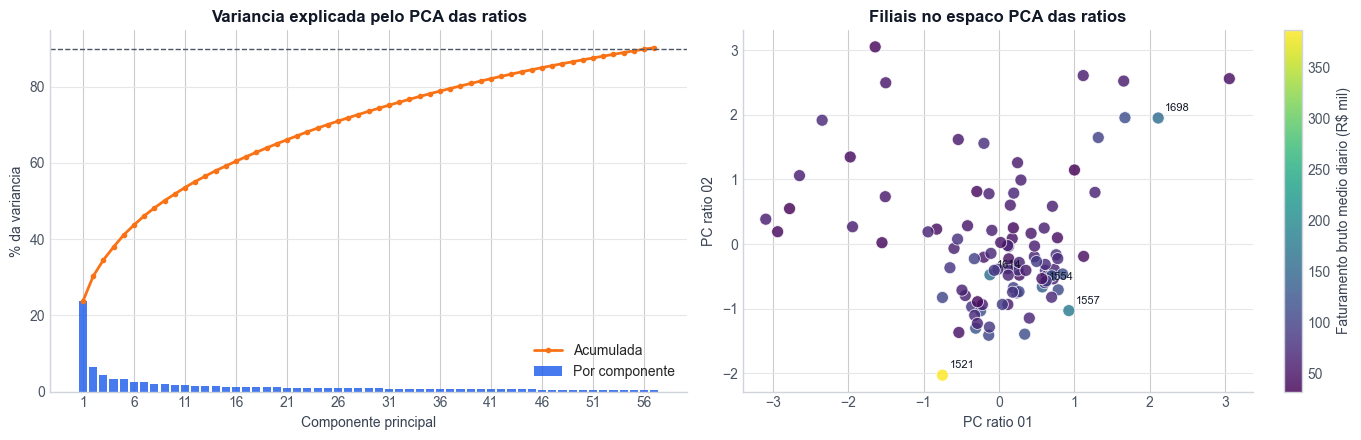

In [9]:
pca_plot = resumo_pca_ratio.copy()
pca_plot["indice"] = np.arange(1, len(pca_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(
    pca_plot["indice"],
    pca_plot["variancia_explicada"] * 100,
    color=PALETA["azul"],
    alpha=0.85,
    label="Por componente",
)
axes[0].plot(
    pca_plot["indice"],
    pca_plot["variancia_explicada_acumulada"] * 100,
    color=PALETA["laranja"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Acumulada",
)
axes[0].axhline(
    PCA_VARIANCIA_RATIO * 100,
    color=PALETA["cinza"],
    linestyle="--",
    linewidth=1,
)
axes[0].set_title("Variancia explicada pelo PCA das ratios")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("% da variancia")
axes[0].set_xticks(np.arange(1, len(pca_plot) + 1, 5))
axes[0].legend()
limpar_eixo(axes[0])

pc_filiais = (
    features_cluster_pca[["codigo_filial", "pc_ratio_01", "pc_ratio_02"]]
    .merge(
        features_agregadas[["codigo_filial", "faturamento_bruto_medio_dia"]],
        on="codigo_filial",
        how="left",
    )
)

scatter = axes[1].scatter(
    pc_filiais["pc_ratio_01"],
    pc_filiais["pc_ratio_02"],
    c=pc_filiais["faturamento_bruto_medio_dia"] / 1000,
    cmap="viridis",
    s=75,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.6,
)

top_filiais = pc_filiais.nlargest(5, "faturamento_bruto_medio_dia")
for _, linha in top_filiais.iterrows():
    axes[1].annotate(
        linha["codigo_filial"],
        (linha["pc_ratio_01"], linha["pc_ratio_02"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
        color="#111827",
    )

axes[1].set_title("Filiais no espaco PCA das ratios")
axes[1].set_xlabel("PC ratio 01")
axes[1].set_ylabel("PC ratio 02")
limpar_eixo(axes[1])

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label("Faturamento bruto medio diario (R$ mil)")

plt.tight_layout()
plt.show()


## Dicionário da Base Agregada

Explicação coluna por coluna da `features_filiais_agregadas_V2`, que resume a base diária por filial.

| coluna | descrição | como foi feita |
|---|---|---|
| `codigo_filial` | Identificador da filial. | Chave da base diária, uma linha final por filial. |
| `faixa_vida` | Faixa de idade/vida da filial. | Vem de `filiais_V1`, via base diária. |
| `tipo_estabelecimento` | Tipo cadastral da filial. | Vem de `filiais_V1`, via base diária. |
| `delivery` | Indicador cadastral de delivery. | Vem de `filiais_V1`, via base diária. |
| `metragem_area_venda` | Metragem da área de venda. | Vem de `filiais_V1`, via base diária. |
| `panvel_clinic` | Indicador cadastral de Panvel Clinic. | Vem de `filiais_V1`, via base diária. |
| `grupo_metragem` | Faixa/grupo de metragem da filial. | Vem de `filiais_V1`, via base diária. |
| `dias_total` | Quantidade de dias na série da filial. | Contagem de linhas da base diária por filial. |
| `dias_com_venda_total` | Quantidade de dias com venda. | Soma de `teve_venda`. |
| `pct_dias_com_venda` | Proporção de dias com venda. | `dias_com_venda_total / dias_total`. |
| `faturamento_bruto_total` | Faturamento bruto total. | Soma de `faturamento_bruto_dia`. |
| `faturamento_bruto_medio_dia` | Média diária do faturamento bruto. | Média de `faturamento_bruto_dia`. |
| `faturamento_bruto_mediano_dia` | Mediana diária do faturamento bruto. | Mediana de `faturamento_bruto_dia`. |
| `faturamento_bruto_std_dia` | Oscilação diária do faturamento bruto. | Desvio padrão de `faturamento_bruto_dia`. |
| `faturamento_bruto_max_dia` | Maior faturamento bruto diário. | Máximo de `faturamento_bruto_dia`. |
| `faturamento_bruto_min_dia` | Menor faturamento bruto diário. | Mínimo de `faturamento_bruto_dia`. |
| `quantidade_total` | Quantidade total vendida. | Soma de `quantidade_dia`. |
| `quantidade_media_dia` | Quantidade média diária. | Média de `quantidade_dia`. |
| `cupons_total` | Total de cupons. | Soma de `cupons_dia`. |
| `cupons_medios_dia` | Média diária de cupons. | Média de `cupons_dia`. |
| `ticket_medio_bruto_dia_medio` | Média diária do ticket médio bruto. | Média de `ticket_medio_bruto_dia`. |
| `itens_por_cupom_dia_medio` | Média diária de itens por cupom. | Média de `itens_por_cupom_dia`. |
| `faturamento_med_total` | Faturamento bruto total MED. | Soma de `faturamento_med_dia`. |
| `faturamento_n_med_total` | Faturamento bruto total N-MED. | Soma de `faturamento_n_med_dia`. |
| `quantidade_med_total` | Quantidade total MED. | Soma de `quantidade_med_dia`. |
| `quantidade_n_med_total` | Quantidade total N-MED. | Soma de `quantidade_n_med_dia`. |
| `share_med_faturamento_medio` | Média diária do share bruto MED em faturamento. | Média de `share_med_faturamento`. |
| `share_n_med_faturamento_medio` | Média diária do share bruto N-MED em faturamento. | Média de `share_n_med_faturamento`. |
| `share_med_quantidade_medio` | Média diária do share MED em quantidade. | Média de `share_med_quantidade`. |
| `share_n_med_quantidade_medio` | Média diária do share N-MED em quantidade. | Média de `share_n_med_quantidade`. |
| `cv_faturamento_bruto_dia` | Volatilidade relativa do faturamento bruto diário. | `faturamento_bruto_std_dia / faturamento_bruto_medio_dia`. |
| `share_med_faturamento_total` | Share bruto MED no faturamento total. | `faturamento_med_total / (faturamento_med_total + faturamento_n_med_total)`. |
| `share_n_med_faturamento_total` | Share bruto N-MED no faturamento total. | `faturamento_n_med_total / (faturamento_med_total + faturamento_n_med_total)`. |
| `share_med_quantidade_total` | Share MED na quantidade total. | `quantidade_med_total / (quantidade_med_total + quantidade_n_med_total)`. |
| `share_n_med_quantidade_total` | Share N-MED na quantidade total. | `quantidade_n_med_total / (quantidade_med_total + quantidade_n_med_total)`. |
| `faturamento_bruto_media_calendario_medio` | Média das médias de faturamento bruto por perfil de calendário da filial. | Primeiro calcula a média por `codigo_filial + mes + semana_mes + dia_semana_num`; depois tira a média desses perfis por filial. |
| `faturamento_bruto_std_calendario_medio` | Média dos desvios padrão de faturamento bruto por perfil de calendário. | Média de `faturamento_bruto_std_mes_semana_dia` entre os perfis de calendário da filial. |
| `faturamento_bruto_cv_calendario_medio` | Média da volatilidade relativa por perfil de calendário. | Média de `faturamento_bruto_cv_mes_semana_dia` entre os perfis de calendário da filial. |
| `faturamento_bruto_ratio_calendario_medio` | Média da força relativa por perfil de calendário. | Média de `faturamento_bruto_ratio_mes_semana_dia` entre os perfis de calendário da filial. |
| `faturamento_bruto_obs_calendario_medio` | Média de observações por perfil de calendário. | Média de `faturamento_bruto_obs_mes_semana_dia` entre os perfis da filial. |
| `faturamento_bruto_obs_calendario_min` | Menor quantidade de observações em um perfil de calendário. | Mínimo de `faturamento_bruto_obs_mes_semana_dia`; ajuda a identificar perfis mais raros, como semana 5. |
| `faturamento_bruto_obs_calendario_max` | Maior quantidade de observações em um perfil de calendário. | Máximo de `faturamento_bruto_obs_mes_semana_dia`. |
| `slots_calendario_total` | Quantidade de perfis de calendário observados na filial. | Contagem de combinações distintas `mes + semana_mes + dia_semana_num`. |


## Dicionário da Base Agregada Cluster

Explicação da variável `features_agregadas_cluster`, que é a versão wide da base agregada para estudo temporal. Ela não é salva por padrão.

Ela parte da `features_agregadas` e adiciona colunas pivotadas para cada combinação:

`mes + semana_mes + dia_semana_num`

Exemplo de chave: `mes01_sem1_dow0` representa janeiro, semana 1 do mês, segunda-feira.

| padrão de coluna | descrição | como foi feita |
|---|---|---|
| `ratio_mesXX_semY_dowZ` | Força relativa do faturamento bruto naquele slot de calendário. | `faturamento_bruto_ratio_mes_semana_dia` pivotado por filial; nulos recebem 1, que representa comportamento neutro. |
| `cv_mesXX_semY_dowZ` | Volatilidade relativa naquele slot de calendário. | `faturamento_bruto_cv_mes_semana_dia` pivotado por filial; nulos recebem 0. |
| `obs_mesXX_semY_dowZ` | Quantidade de observações daquele slot de calendário. | `faturamento_bruto_obs_mes_semana_dia` pivotado por filial; nulos recebem 0. |

Essa base é mais larga porque transforma o perfil temporal em colunas. Isso facilita estudar sazonalidade, mas ficou detalhada demais para ser mantida como arquivo permanente nesta etapa.


## Dicionário da Base Cluster PCA

Explicação da variável `features_cluster_pca`, criada para testar a redução dimensional dos ratios `mes x semana x dia`. Ela não é salva por padrão.

Ela parte de `features_agregadas_cluster`, mas trata os blocos de features de formas diferentes:

| padrão de coluna | descrição | como foi feita |
|---|---|---|
| `codigo_filial` | Identificador da filial. | Mantido sem transformação para rastrear cada linha. |
| `num__...` | Features gerais numéricas tratadas. | Colunas numéricas da agregada normal, sem os pivots wide `ratio_mes`, `cv_mes` e `obs_mes`; valores nulos tratados e depois `StandardScaler`. |
| `cat__...` | Features gerais categóricas tratadas. | Colunas categóricas da agregada normal com `OneHotEncoder`. |
| `pc_ratio_XX` | Componentes principais do padrão temporal de ratio. | PCA aplicado somente nas colunas `ratio_mesXX_semY_dowZ`, após `StandardScaler`; os componentes também são padronizados para ficarem comparáveis às features gerais. |

Nesta primeira versão, as colunas wide `cv_mesXX_semY_dowZ` e `obs_mesXX_semY_dowZ` não entram na matriz final. O CV temporal pode ser instável em slots com poucas observações, e `obs_` mede disponibilidade da combinação de calendário, não comportamento comercial direto.

A tabela `resumo_pca_ratio` mostra a variância explicada de cada `pc_ratio_XX`.


## Dicionário das Bases Semana-Dia

Essas bases são alternativas mais estáveis para clusterização, com menor granularidade temporal.

### Variável `features_agregadas_cluster_semana_dia`

Base wide auxiliar, uma linha por filial, com:

| padrão de coluna | descrição | como foi feita |
|---|---|---|
| `ratio_semana_dia_semY_dowZ` | Força relativa daquele slot semana do mês + dia da semana. | Média de `faturamento_bruto_dia` por `codigo_filial + semana_mes + dia_semana_num` dividida pela média geral da filial. |
| `cv_semana_dia_semY_dowZ` | Volatilidade relativa do slot semana do mês + dia da semana. | Desvio padrão dividido pela média do mesmo slot. Fica como diagnóstico, não entra na matriz final. |
| `obs_semana_dia_semY_dowZ` | Quantidade de observações do slot. | Contagem de dias por `codigo_filial + semana_mes + dia_semana_num`. |
| `ratio_mensal_mesXX` | Força relativa do mês na filial. | Média de `faturamento_bruto_dia` por `codigo_filial + mes` dividida pela média geral da filial. |

### Checkpoint `features_filiais_cluster_semana_dia_V2.parquet`

Matriz tratada final com:

- features gerais numéricas escaladas;
- features gerais categóricas em one-hot;
- ratios `semana_mes x dia_semana_num` escaladas;
- sem PCA, sem `cv_` e sem `obs_`.

### Variável `features_cluster_semana_dia_mes`

Matriz experimental com tudo da matriz final mais as ratios mensais separadas. Ela fica em memória para comparação, mas não é salva como checkpoint oficial.


## Validar, visualizar e salvar checkpoints

Valida chaves e tamanhos das bases criadas, mostra gráficos de leitura geral e salva apenas os checkpoints oficiais da `Base_V2`.


,validacao,valor
0,duplicadas_diarias,0
1,duplicadas_agregadas,0
2,duplicadas_agregadas_cluster,0
3,duplicadas_cluster_pca,0
4,duplicadas_agregadas_cluster_semana_dia,0
5,duplicadas_cluster_semana_dia,0
6,duplicadas_cluster_semana_dia_mes,0
7,filiais_base_diaria,100
8,filiais_base_agregada,100
9,filiais_base_agregada_cluster,100


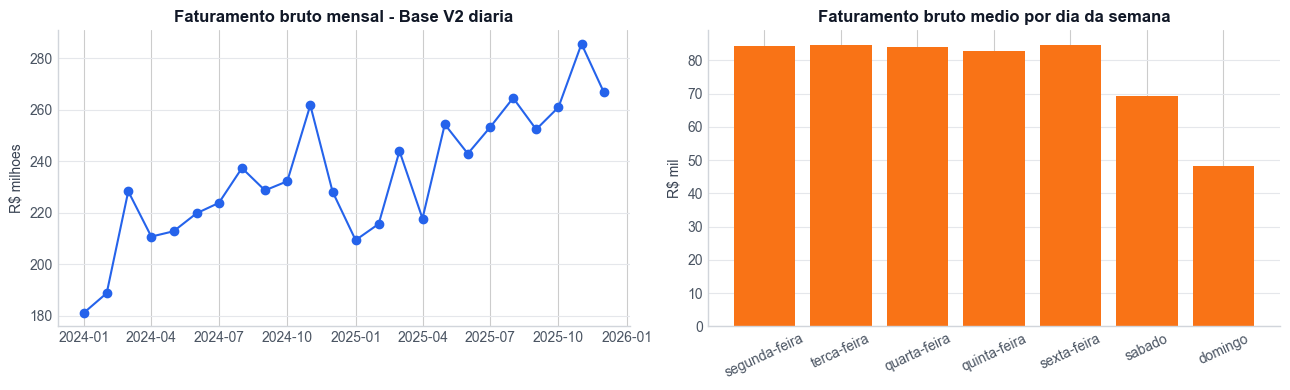

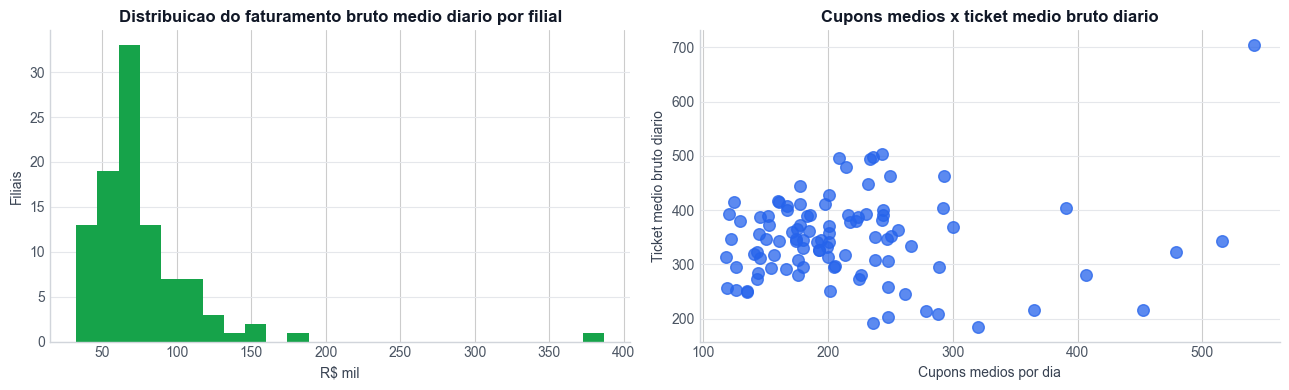

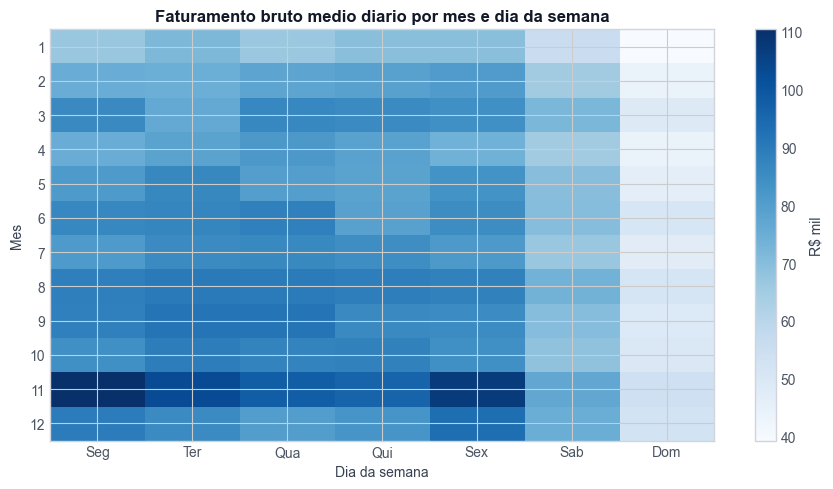

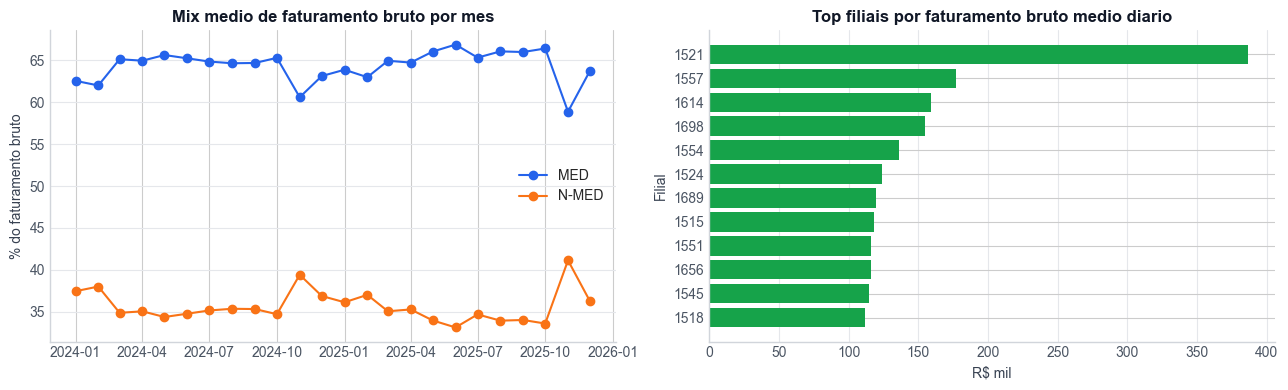

,checkpoint_salvo
features_diarias,E:\trabalhos\PROJ3- Panvel\Base_V2\features_fi...
features_agregadas,E:\trabalhos\PROJ3- Panvel\Base_V2\features_fi...
features_cluster_semana_dia,E:\trabalhos\PROJ3- Panvel\Base_V2\features_fi...


In [10]:
validacao = validar_chaves(
    features_diarias,
    features_agregadas,
    features_agregadas_cluster,
    features_cluster_pca,
    features_agregadas_cluster_semana_dia,
    features_cluster_semana_dia,
    features_cluster_semana_dia_mes,
)
display(validacao)

plotar_resumo_base_v2(features_diarias, features_agregadas)
plotar_visualizacoes_complementares(features_diarias, features_agregadas)

caminhos_salvos = salvar_checkpoints_v2(
    features_diarias,
    features_agregadas,
    features_cluster_semana_dia,
)
display(pd.Series(caminhos_salvos, name="checkpoint_salvo").to_frame())
